Ready — imports OK
Resampling DEM to (512, 512) using device: mps

--- Removing Outer 5 Pixels ---
Original shape: (512, 512)
New shape: (507, 507)

--- Removing Outer 5 Pixels ---
Original shape: (512, 512)
New shape: (507, 507)

--- Removing Outer 5 Pixels ---
Original shape: (512, 512)
New shape: (507, 507)
Image shape: torch.Size([502, 502])
Reflectance map shape: torch.Size([502, 502])


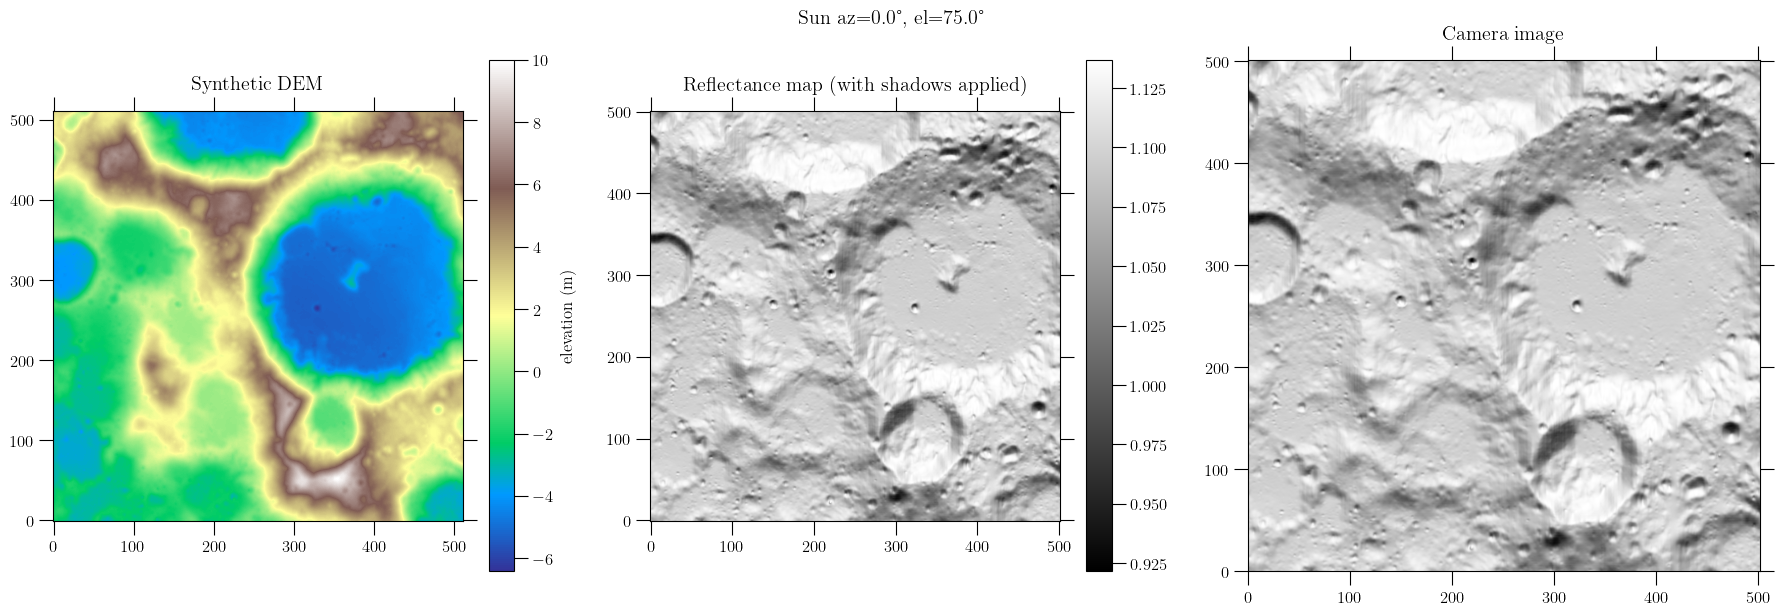

In [2]:
# Imports and parameters
import numpy as np
import matplotlib.pyplot as plt
import torch as torch
import math as math
import torch.nn.functional as F


from master.validate.plotting_new import ax_format
# Project utilities (same folder)
from master.data_sim.generator import _generate_synthetic_dem, _render_single_image
from master.render.dem_utils import DEM
from master.render.hapke_model import HapkeModel, FullHapkeModel
from master.render.camera import Camera
from master.render.renderer import Renderer
from scipy.ndimage import label

from scipy.ndimage import gaussian_filter, zoom

from master.lro_data_sim.lro_generator import generate_and_return_lro_dem
from master.configs.config_utils import load_config_file

from master.FM_solver.solver_utils import remove_outer_n_pixels

# Example parameters (tweak as needed)
config = load_config_file()

DEM_SIZE = 512
IMAGE_W = 512
IMAGE_H = 512
FOCAL_LENGTH = 100000.0
SUN_AZ = 0   # degrees
SUN_EL = 75.0   # degrees
CAM_AZ = 0  # degrees
CAM_EL = 90.0   # degrees
CAM_DIST = 100000.0

print('Ready — imports OK')

# Create a synthetic DEM and show it
# We use the project's generator so the DEM looks like what training uses
np.random.seed(20)
dem_size = 512
n_craters = 0
n_ridges = 0
n_hills = 2

crater_depth_range = (20, 50)
crater_radius_range = (30, 80)
ridge_height_range = (30, 40)
ridge_length_range = (0.05, 0.1)
ridge_width_range = (0.05, 0.1)
hill_height_range = (30, 40)
hill_sigma_range = (0.2, 0.1)

use_synthetic = False
# dem = _generate_synthetic_dem(size=dem_size, 
#                                     n_craters=n_craters, 
#                                     n_ridges=n_ridges, 
#                                     n_hills=n_hills,
#                                     crater_depth_range=crater_depth_range,
#                                     crater_radius_range=crater_radius_range,
#                                     ridge_height_range=ridge_height_range,
#                                     ridge_length_range=ridge_length_range,
#                                     ridge_width_range=ridge_width_range,
#                                     hill_height_range=hill_height_range,
#                                     hill_sigma_range=hill_sigma_range)

file_location = '/Users/au644271/Desktop/local_python/master/lro_data_sim/Lunar_LRO_LOLA_Global_LDEM_118m_Mar2014.tif'

config['HEIGHT_NORMALIZATION'] = 10

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
dem_tensor, lro_meta = generate_and_return_lro_dem(config, file_location=file_location)

device = 'cpu'
dem = dem_tensor.to(device=device, dtype=torch.float32)

dem_obj = DEM(dem, cellsize=1, x0=0, y0=0)
# hapke = FullHapkeModel(w=0.12)
hapke = HapkeModel(w=1, B0=0.4, h=0.1, phase_fun='lambertian', xi=0.1)  # Use simpler Hapke for testing
camera = Camera(image_width=IMAGE_W, image_height=IMAGE_H, focal_length=FOCAL_LENGTH, device='cpu')
renderer = Renderer(dem_obj, hapke, camera)

params = (SUN_AZ, SUN_EL, CAM_AZ, CAM_EL, CAM_DIST)

# render_single_image will compute its own shadow map internally as implemented in the project
img, reflectance_map = _render_single_image(renderer=renderer, params=params, image_w=IMAGE_W, image_h=IMAGE_H)

# remover outer pixel around reflectance map
img = remove_outer_n_pixels(img, 5, debug=True)
reflectance_map = remove_outer_n_pixels(reflectance_map, 5, debug=True)
dem = remove_outer_n_pixels(dem, 5, debug=True)
print('Image shape:', img.shape)
print('Reflectance map shape:', reflectance_map.shape)

# Plot reflectance map and camera image using subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if use_synthetic:
    dem_array = dem
else:
    dem_array = dem_tensor.cpu().numpy()

ax = axes[0]
ax.imshow(dem_array, cmap='terrain', origin='lower')
ax.set_title('Synthetic DEM', pad=15)
fig.colorbar(ax.images[0], ax=ax, label='elevation (m)')
ax_format(ax)

ax = axes[1]
ax.imshow(reflectance_map.cpu().numpy(), cmap='gray', origin='lower')
ax.set_title('Reflectance map (with shadows applied)', pad=15)
fig.colorbar(ax.images[0], ax=ax)
ax_format(ax)

ax = axes[2]
ax.imshow(img.cpu().numpy(), cmap='gray', origin='lower')
ax.set_title('Camera image', pad=15)
ax_format(ax)

fig.suptitle(f"Sun az={SUN_AZ:.1f}°, el={SUN_EL:.1f}°")
fig.tight_layout()
plt.show()


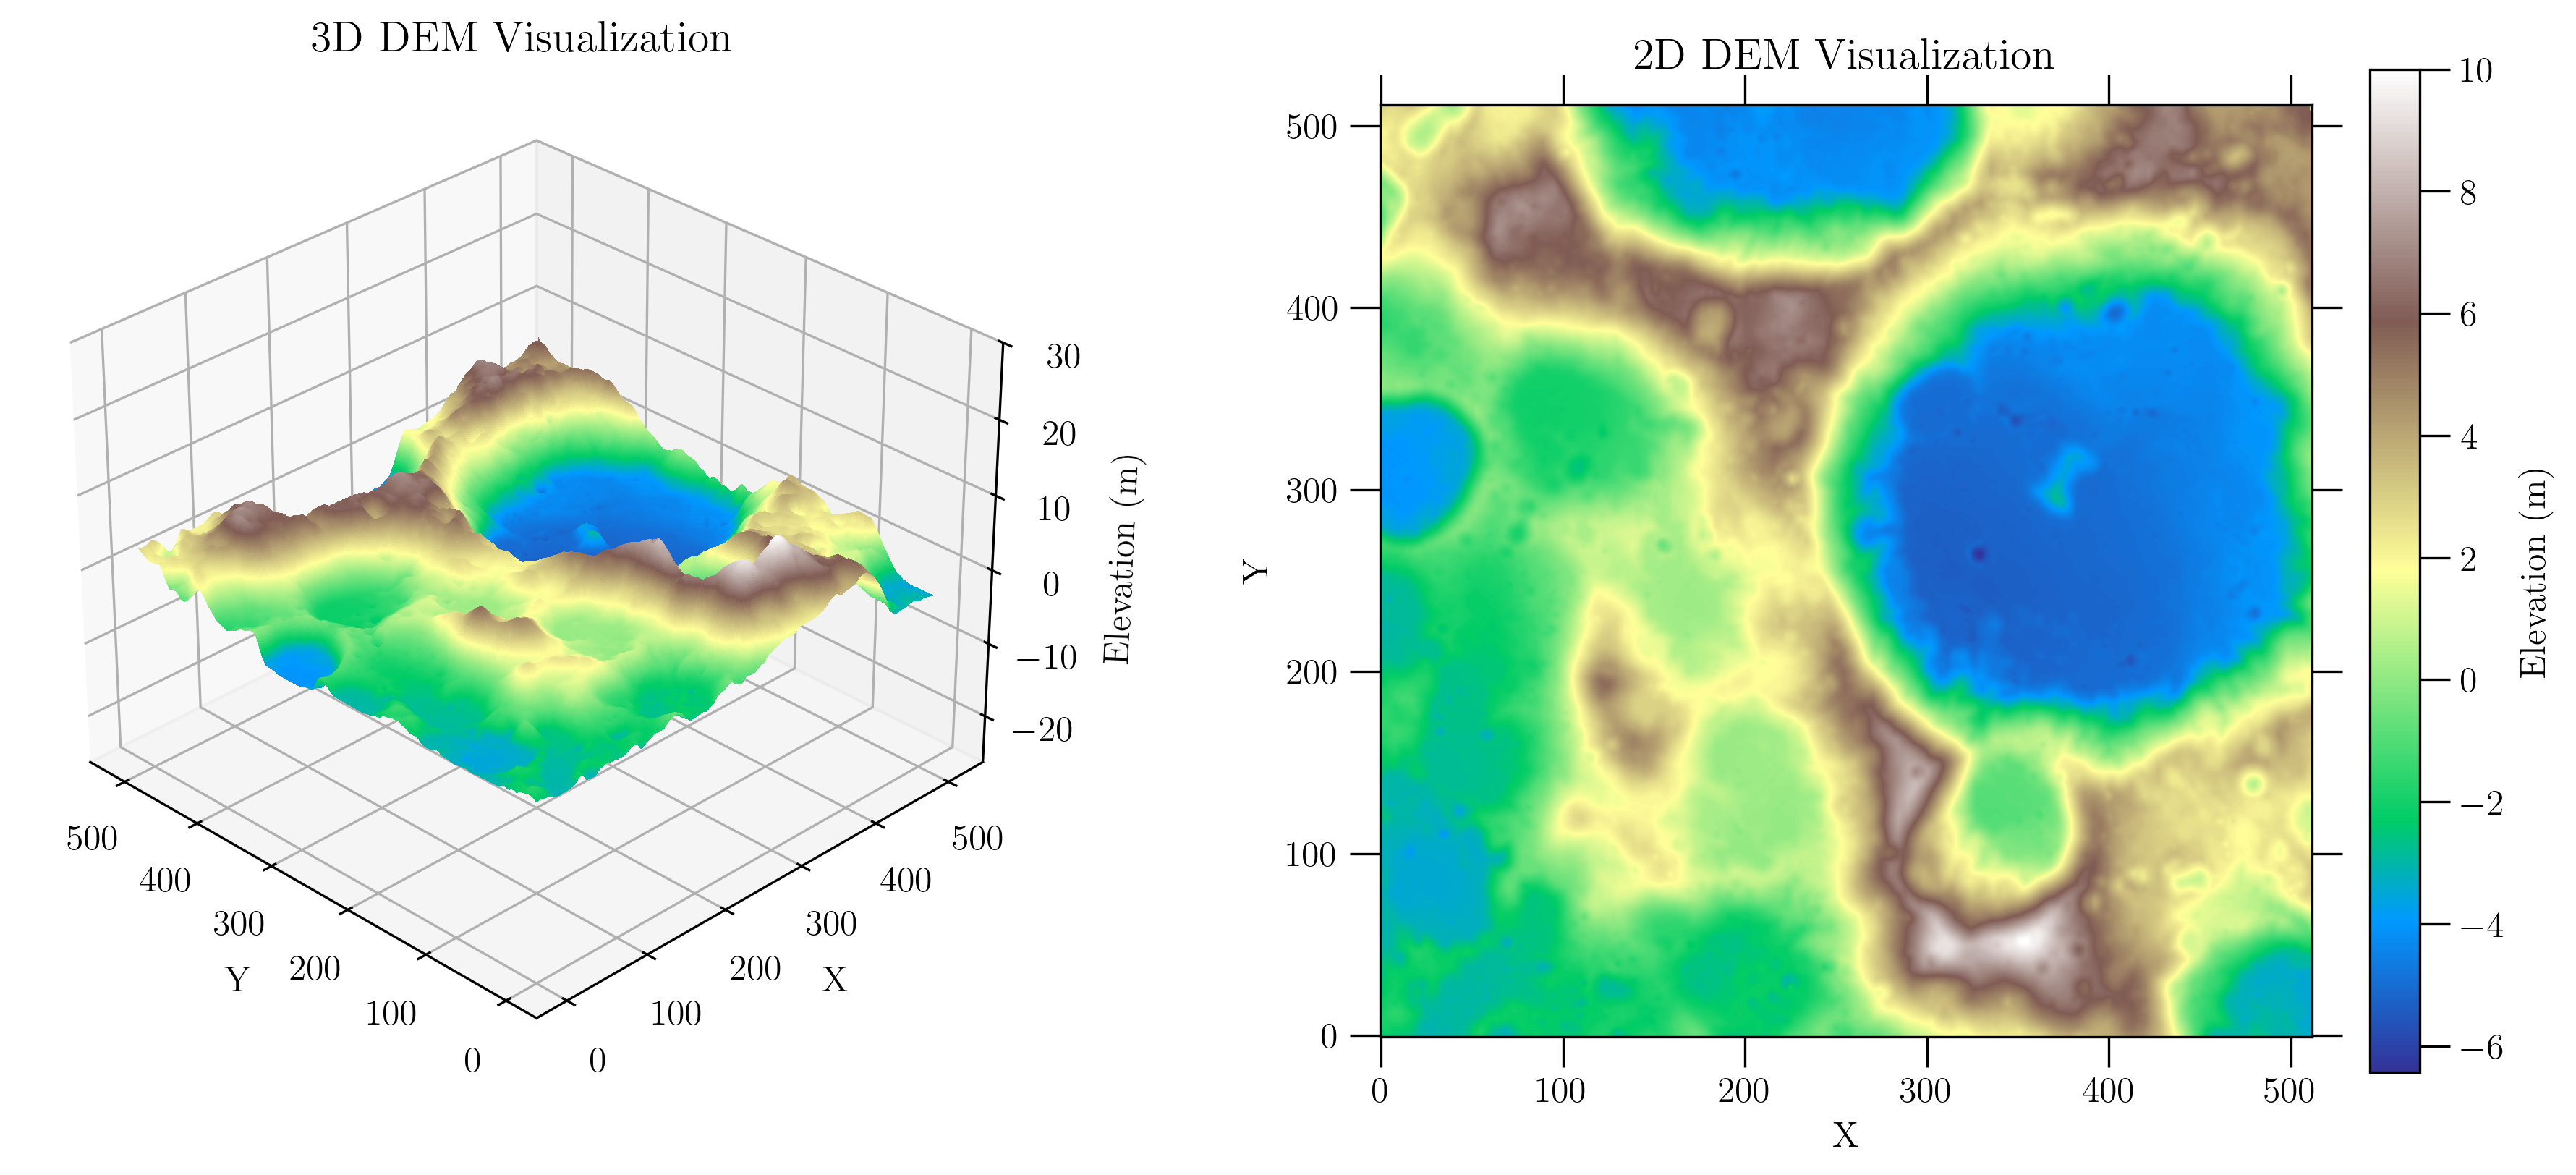

In [30]:
# make 2D and 3D plot of dem side by side
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6), dpi=300)
gs = gridspec.GridSpec(1, 2, width_ratios=[1.15, 1], wspace=0.15)

# 3D plot (now on the left)
ax1 = fig.add_subplot(gs[0], projection='3d')
X = np.arange(dem_array.shape[1])
Y = np.arange(dem_array.shape[0])
X, Y = np.meshgrid(X, Y)
Z = dem_array
ax1.plot_surface(Y, X, Z, cmap='terrain', edgecolor='none', 
                 rstride=1, cstride=1, antialiased=True, linewidth=0, 
                 alpha=1.0, shade=True, rasterized=True)
ax1.set_title('3D DEM Visualization')
ax1.view_init(elev=30, azim=-45)  # Adjust view angle for better visualization
ax1.set_zlim(np.min(Z)-20, np.max(Z)+20)  # Set z limits to match DEM range
ax1.set_xlabel('Y')
ax1.set_ylabel('X')
ax1.invert_xaxis()
ax1.set_zlabel('Elevation (m)')

# 2D plot with terrain colors (now on the right)
ax2 = fig.add_subplot(gs[1])
im = ax2.imshow(dem_array, cmap='terrain', origin='lower')

ax2.set_title('2D DEM Visualization', pad=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
fig.colorbar(im, ax=ax2, label='Elevation (m)')
ax_format(ax2)

plt.savefig('dem_visualization.pdf', dpi=300, bbox_inches='tight')
plt.show()



--- Removing Outer 5 Pixels ---
Original shape: (512, 512)
New shape: (507, 507)

--- Removing Outer 5 Pixels ---
Original shape: (512, 512)
New shape: (507, 507)
vmax: 1.1369277238845825, vmin: 0.9031528234481812


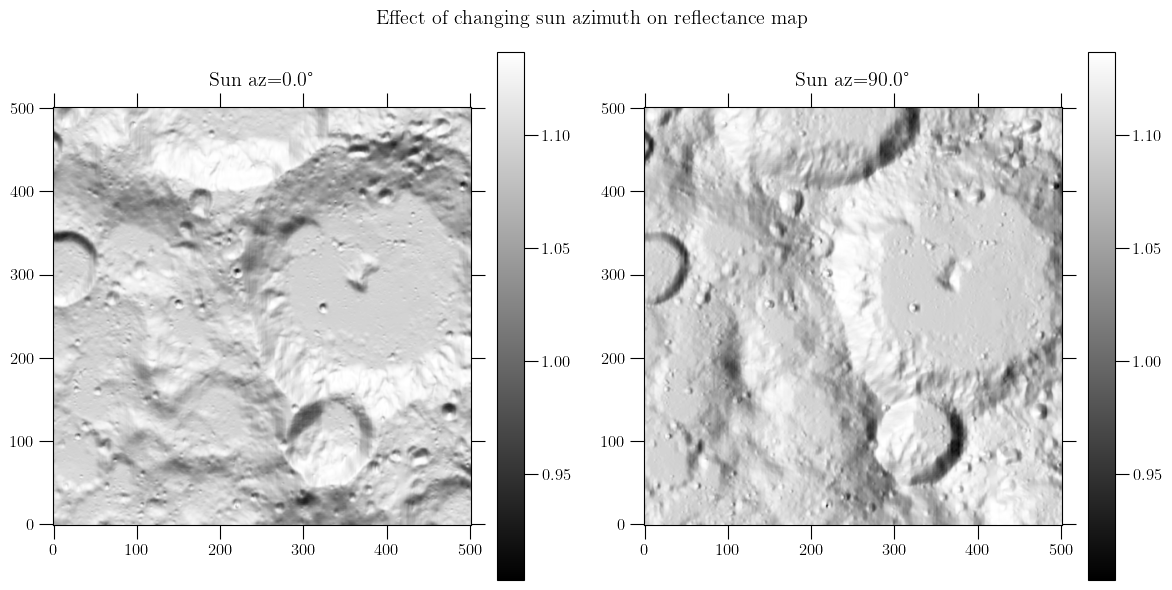

In [3]:
# Render two reflectance maps, with sun illumination changing
SUN_AZ_2 = 90
params_2 = (SUN_AZ_2, SUN_EL, CAM_AZ, CAM_EL, CAM_DIST)
#print all vals nicely
img_2, reflectance_map_2 = _render_single_image(renderer=renderer, params=params_2, image_w=IMAGE_W, image_h=IMAGE_H)

img_2 = remove_outer_n_pixels(img_2, 5, debug=True)
reflectance_map_2 = remove_outer_n_pixels(reflectance_map_2, 5, debug=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
reflectance_np = reflectance_map.detach().cpu().numpy()
reflectance_np_2 = reflectance_map_2.detach().cpu().numpy()

# vmax = np.mean(reflectance_np) + 1 * np.std(reflectance_np)
# vmin = np.mean(reflectance_np) - 2 * np.std(reflectance_np)

# vmax = np.max(reflectance_np)
# vmin = np.min(reflectance_np)
vmax = np.max([reflectance_np.max(), reflectance_np_2.max()])
vmin = np.min([reflectance_np.min(), reflectance_np_2.min()])
print(f"vmax: {vmax}, vmin: {vmin}")

ax = axes[0]
ax.imshow(reflectance_np, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
ax.set_title(f'Sun az={SUN_AZ:.1f}°', pad=15)
fig.colorbar(ax.images[0], ax=ax)
ax_format(ax)

ax = axes[1]
ax.imshow(reflectance_np_2, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
ax.set_title(f'Sun az={SUN_AZ_2:.1f}°', pad=15)
fig.colorbar(ax.images[0], ax=ax)
ax_format(ax)

fig.suptitle("Effect of changing sun azimuth on reflectance map")
fig.tight_layout()
plt.show()

In [4]:
# Import refactored FMSolver instead of inline class definition
from master.FM_solver.solver import FMSolver

print("FMSolver imported successfully from master.FM_solver.solver")
print("Refactored version includes:")
print("  - Comprehensive debug mode (set debug=True)")
print("  - Coordinate system validation")
print("  - Normal field validation against ground truth")
print("  - Gradient computation with sign convention checks")
print("  - Utilities extracted to solver_utils.py")

FMSolver imported successfully from master.FM_solver.solver
Refactored version includes:
  - Comprehensive debug mode (set debug=True)
  - Coordinate system validation
  - Normal field validation against ground truth
  - Gradient computation with sign convention checks
  - Utilities extracted to solver_utils.py


[FMSolver] ======================================================================
[FMSolver] Initializing FMSolver
[FMSolver] ======================================================================
[FMSolver] Number of illumination angles: 2
[FMSolver] Sun azimuths: [0, 90]°
[FMSolver] Sun elevation: 75.0°
[FMSolver] Reflectance map shape: (502, 502)
[FMSolver] Vectorized reflectance shape: (252004, 2)
[FMSolver] Ground truth DEM shape: (502, 502)
[FMSolver] DEM elevation range: [-6.43, 10.00]
[FMSolver] 
--- Computing Sun Direction Vectors ---
[FMSolver]   Sun 0: az=0.0°, el=75.0° North
[FMSolver]     Vector: [+0.0000, +0.2588, +0.9659]
[FMSolver]     |v| = 1.000000 (should be 1.0)
[FMSolver]   Sun 1: az=90.0°, el=75.0° East
[FMSolver]     Vector: [+0.2588, +0.0000, +0.9659]
[FMSolver]     |v| = 1.000000 (should be 1.0)
[FMSolver] 
--- Validating Sun Vectors ---
[FMSolver]   ✓ All sun vectors are unit length
[FMSolver]   ✓ All sun vectors above horizon (z > 0)
[FMSolver] 
--- Setting N

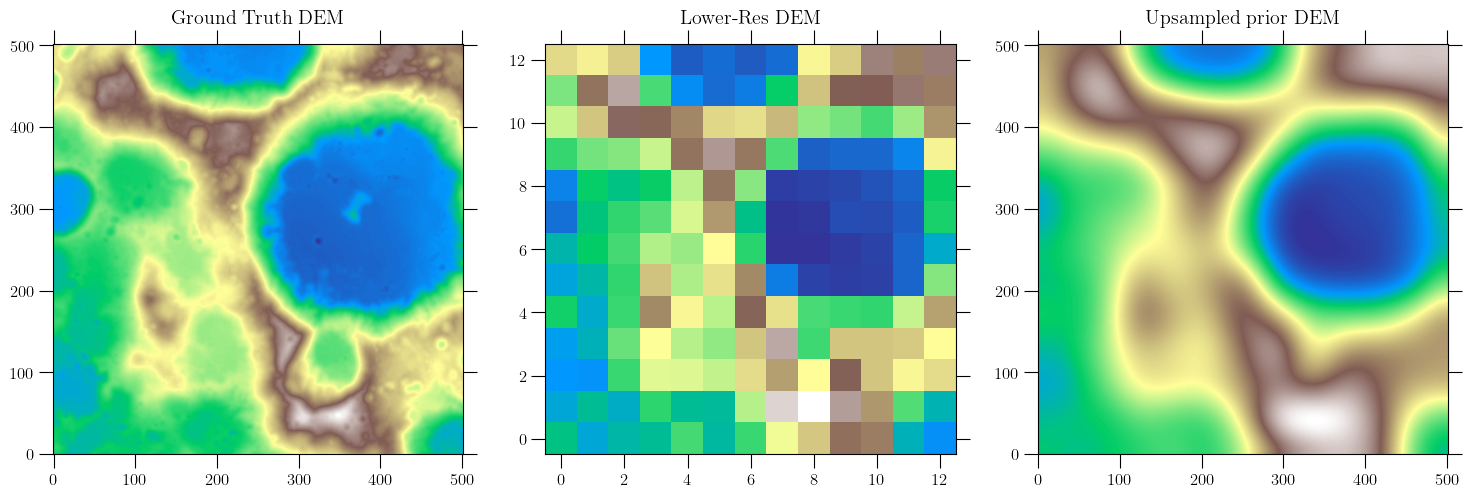

In [ ]:
# test normal solver one step at a time

# Use refactored FMSolver with debug mode enabled
normal_solver = FMSolver(
    reflectance_maps=[reflectance_map, reflectance_map_2], 
    sun_azs=[SUN_AZ, SUN_AZ_2], 
    sun_el=SUN_EL, 
    gt_dem=dem, 
    scale_down_factor=40,
    debug=True  # Enable comprehensive debug output
)

#plot gt_dem vs prior_dem vs dem_lower_res
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(normal_solver.gt_dem, cmap='terrain', origin='lower')
axes[0].set_title('Ground Truth DEM', pad=15)

axes[1].imshow(normal_solver.dem_lower, cmap='terrain', origin='lower')
axes[1].set_title('Lower-Res DEM', pad=15)

axes[2].imshow(normal_solver.dem_prior, cmap='terrain', origin='lower')
axes[2].set_title('Upsampled prior DEM', pad=15)
plt.show()


In [6]:
# Check illumination vectors for constitensy
print("Sun normals shape:", normal_solver.sun_normals.shape)
print("Sun Azs:", normal_solver.sun_azs)
print("Sun El:", normal_solver.sun_el)
print("Sun normals values:", normal_solver.sun_normals)

Sun normals shape: (2, 3)
Sun Azs: [0, 90]
Sun El: 75.0
Sun normals values: [[0.00000000e+00 2.58819045e-01 9.65925826e-01]
 [2.58819045e-01 1.58480958e-17 9.65925826e-01]]


Setting covariance prior with max slope 30 degrees (variance: 0.274156 rad^2)
Setting brightness covariance with variance: 0.000129 (std: 0.011369) based on max reflectance: 1.136928
Removed outer 5 pixels. New shape: (502, 502)


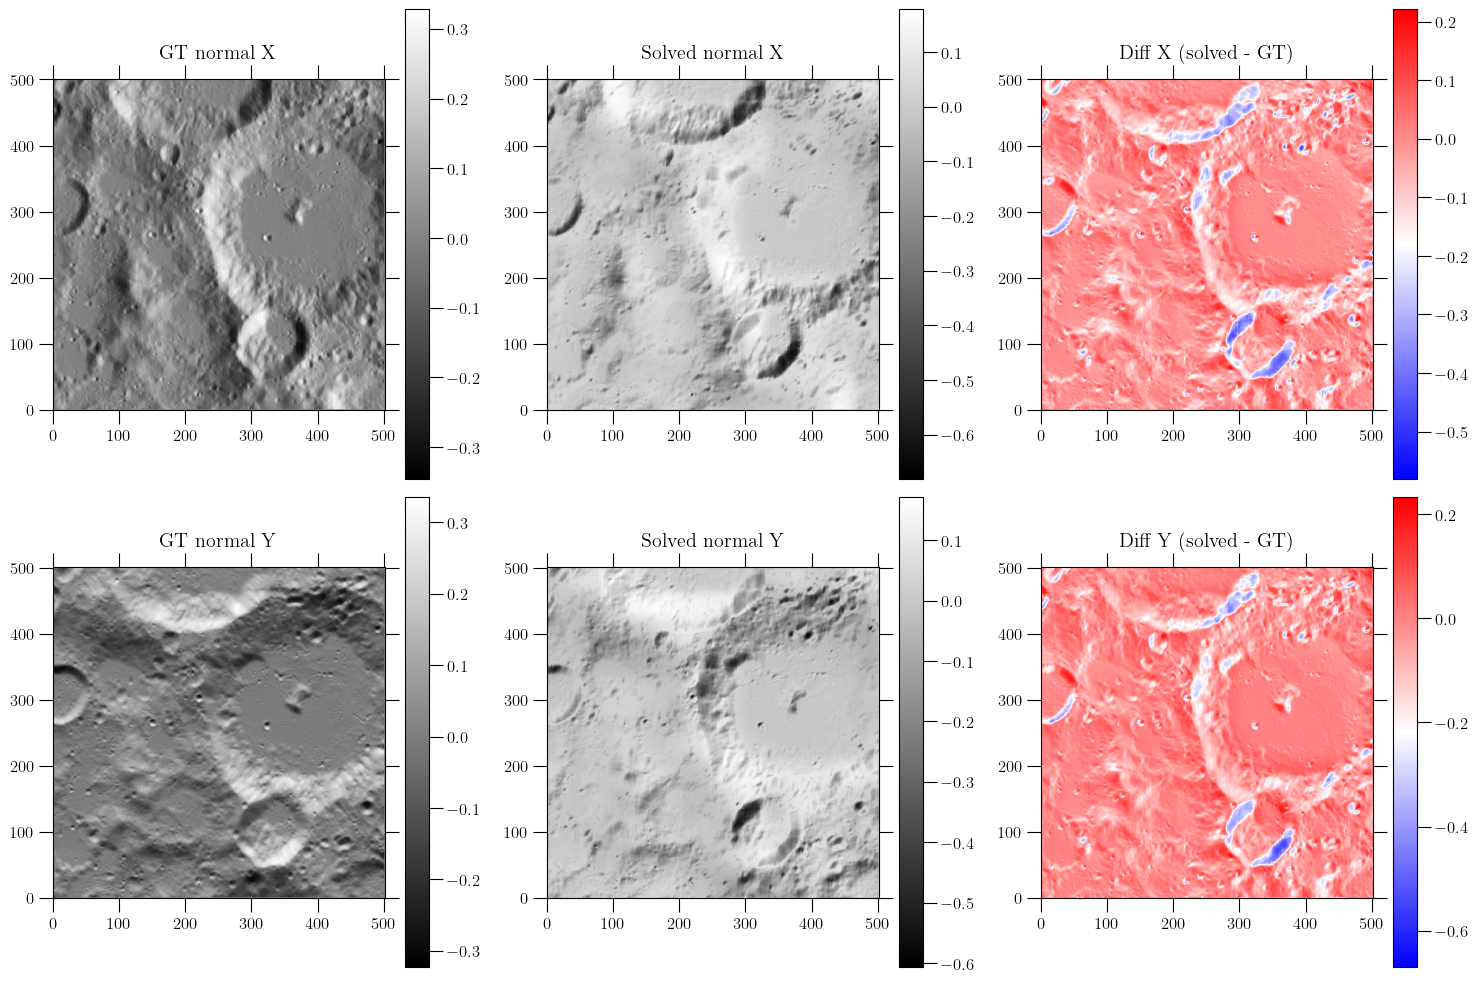

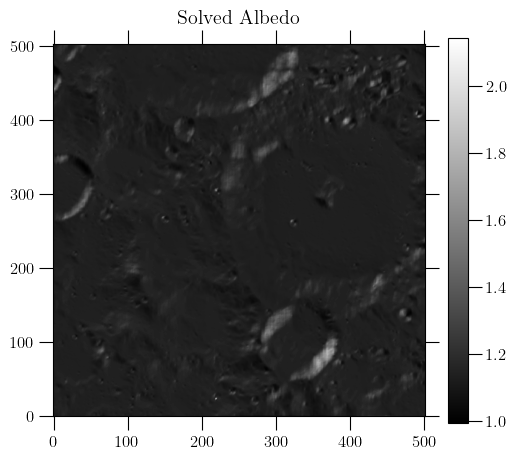

Estimated albedo stats: min 0.9953, max 2.1437, mean 1.1474, std 0.0474
torch.Size([502, 502])
Correlation albedo vs reflectance: 0.030033186853941962

Solved albedo percentiles:
    0%: 0.995318
    1%: 1.076383
    5%: 1.104833
   25%: 1.130767
   50%: 1.138833
   75%: 1.150893
   95%: 1.212182
   99%: 1.369712
  100%: 2.143737


In [ ]:
gt_normals = normal_solver.compute_normals_from_dem(normal_solver.gt_dem)
# solved_normals, solved_albedos = normal_solver.solve_normals_analytical()
solved_normals, solved_albedos = normal_solver.estimate_normal_and_albedo()


# normals_lower_res = normal_solver.compute_normals_from_dem(normal_solver.dem_lower_res)

# compare x/y components: gt vs solved and difference


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

im = axes[0, 0].imshow(gt_x, cmap='grey', origin='lower')
axes[0, 0].set_title('GT normal X', pad=15)
fig.colorbar(im, ax=axes[0, 0])

im = axes[0, 1].imshow(solved_x, cmap='grey', origin='lower')
axes[0, 1].set_title('Solved normal X', pad=15)
fig.colorbar(im, ax=axes[0, 1])


im = axes[0, 2].imshow(diff_x, cmap='bwr', origin='lower')
axes[0, 2].set_title('Diff X (solved - GT)', pad=15)
fig.colorbar(im, ax=axes[0, 2])

im = axes[1, 0].imshow(gt_y, cmap='grey', origin='lower')
axes[1, 0].set_title('GT normal Y', pad=15)
fig.colorbar(im, ax=axes[1, 0])

im = axes[1, 1].imshow(solved_y, cmap='grey', origin='lower')
axes[1, 1].set_title('Solved normal Y', pad=15)
fig.colorbar(im, ax=axes[1, 1])

im = axes[1, 2].imshow(diff_y, cmap='bwr', origin='lower')
axes[1, 2].set_title('Diff Y (solved - GT)', pad=15)
fig.colorbar(im, ax=axes[1, 2])


plt.tight_layout()
plt.show()


# plot solved albedo
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(solved_albedos, cmap='gray', origin='lower')
ax.set_title('Solved Albedo', pad=15)
fig.colorbar(im, ax=ax)
plt.show()

print("Estimated albedo stats: min {:.4f}, max {:.4f}, mean {:.4f}, std {:.4f}".format(solved_albedos.min(), solved_albedos.max(), solved_albedos.mean(), solved_albedos.std()))

H,W = reflectance_map.shape
n = 5 
refl = reflectance_map[n:H-n, n:W-n]
print(refl.shape)
corr = np.corrcoef(solved_albedos.flatten(), refl.flatten())[0,1] 
print("Correlation albedo vs reflectance:", corr)

percentiles = np.percentile(solved_albedos, [0, 1, 5, 25, 50, 75, 95, 99, 100])
print("\nSolved albedo percentiles:")
for p, val in zip([0, 1, 5, 25, 50, 75, 95, 99, 100], percentiles):
    print(f"  {p:3d}%: {val:.6f}")

In [7]:

normals_gt = normal_solver.compute_normals_from_dem(normal_solver.dem_prior)

df_dx_from_prior = -normals_gt[...,0] / normals_gt[...,2]
df_dy_from_prior = -normals_gt[...,1] / normals_gt[...,2]

corr_x = np.corrcoef(df_dx_from_prior.flatten(), df_dx_prior.flatten())[0,1]
corr_y = np.corrcoef(df_dy_from_prior.flatten(), df_dy_prior.flatten())[0,1]

print(corr_x, corr_y)


NameError: name 'df_dx_prior' is not defined

n_prior z-component stats - min: 0.9232694422368434, max: 1.0, mean: 0.9918206507071178
n3 stats - min: 0.6267410780616496, max: 0.9999999979422367, mean: 0.9890711815657537
df/dx stats - min: -1.0875305830852338, max: 0.18124579745553376, mean: -0.03733079757226635
df/dy stats - min: -0.8180040055762962, max: 0.17391304144680828, mean: -0.03275755154653503
gt_x stats - min: -0.34591988005669005, max: 0.328247915984564, mean: -0.005381003500956839
gt_y stats - min: -0.3233648552552053, max: 0.33517829484174355, mean: -0.0012403328166865465
diff_x stats - min: -0.8386405535572192, max: 0.2215510283095791, mean: -0.03194979407130951
diff_y stats - min: -0.8951773816066, max: 0.2324910188628684, mean: -0.03151721872984849


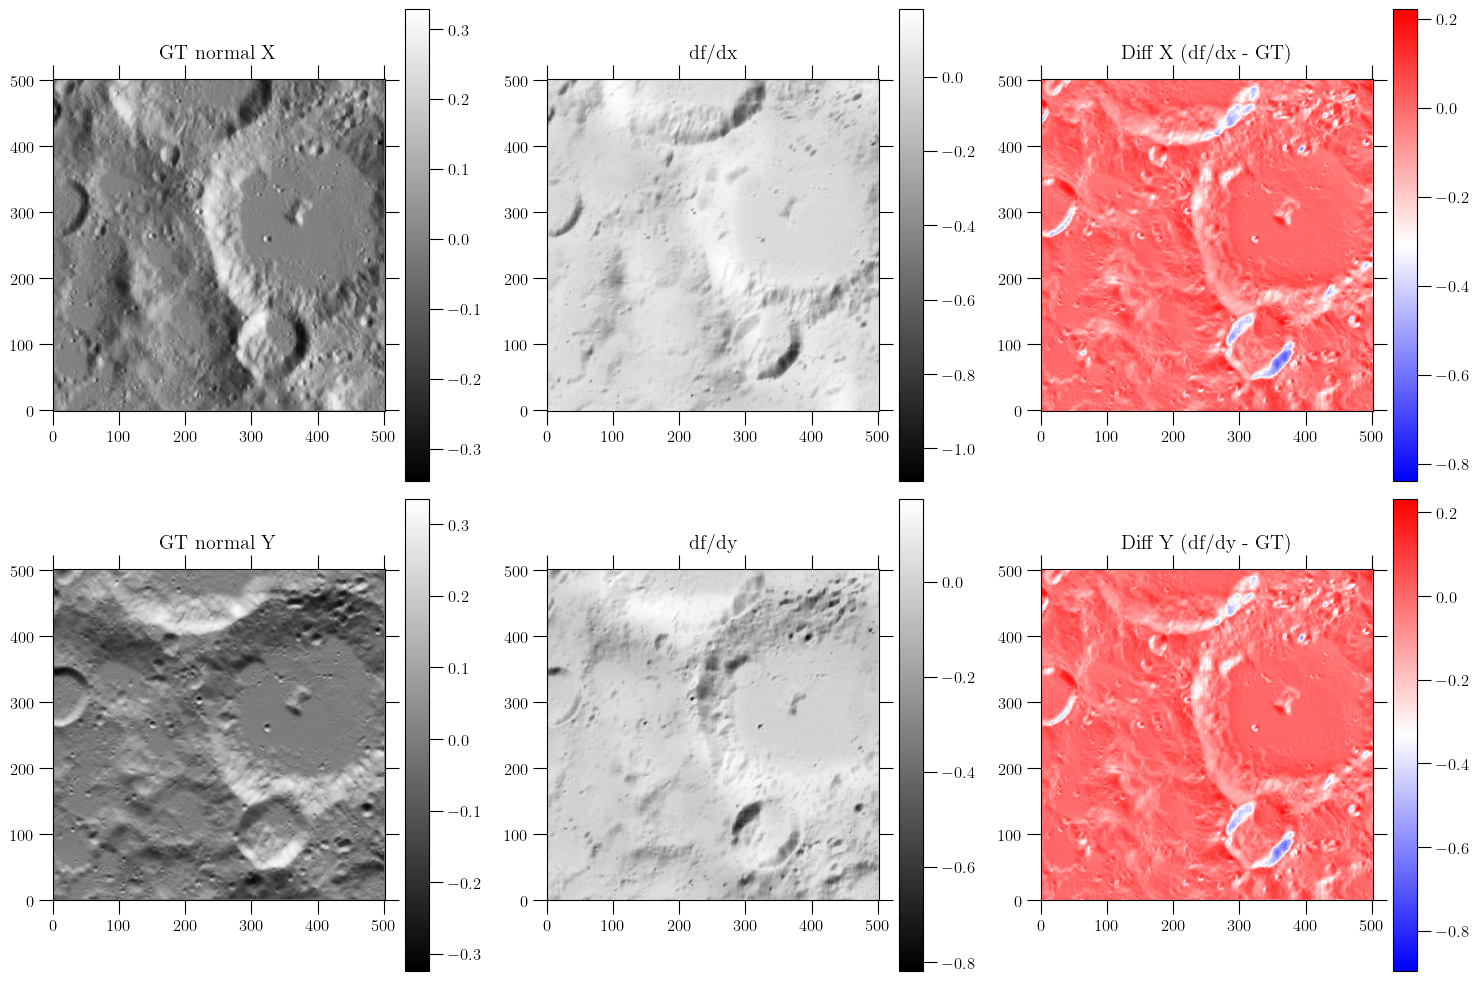

In [ ]:
# print("Reflectance map stats:")
# for i, rm in enumerate([reflectance_map, reflectance_map_2]):
#     print(f"  Map {i}: min={rm.min()}, max={rm.max()}, mean={rm.mean()}")

gt_z = gt_normals[..., 2]
print(f"n_prior z-component stats - min: {np.min(gt_z)}, max: {np.max(gt_z)}, mean: {np.mean(gt_z)}")

# now calculate actual df/dx and df/dy by using n3
n3 = solved_normals[..., 2]
print(f"n3 stats - min: {n3.min()}, max: {n3.max()}, mean: {n3.mean()}")
df_dx = solved_normals[..., 0] / n3
print(f"df/dx stats - min: {df_dx.min()}, max: {df_dx.max()}, mean: {df_dx.mean()}")
df_dy = solved_normals[..., 1] / n3
print(f"df/dy stats - min: {df_dy.min()}, max: {df_dy.max()}, mean: {df_dy.mean()}")

print(f"gt_x stats - min: {gt_x.min()}, max: {gt_x.max()}, mean: {gt_x.mean()}")
print(f"gt_y stats - min: {gt_y.min()}, max: {gt_y.max()}, mean: {gt_y.mean()}")
diff_x = df_dx - gt_x
diff_y = df_dy - gt_y
print(f"diff_x stats - min: {diff_x.min()}, max: {diff_x.max()}, mean: {diff_x.mean()}")
print(f"diff_y stats - min: {diff_y.min()}, max: {diff_y.max()}, mean: {diff_y.mean()}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

im = axes[0, 0].imshow(gt_x, cmap='grey', origin='lower')
axes[0, 0].set_title('GT normal X', pad=15)
fig.colorbar(im, ax=axes[0, 0])

im = axes[0, 1].imshow(df_dx, cmap='grey', origin='lower')
axes[0, 1].set_title('df/dx', pad=15)
fig.colorbar(im, ax=axes[0, 1])


im = axes[0, 2].imshow(diff_x, cmap='bwr', origin='lower')
axes[0, 2].set_title('Diff X (df/dx - GT)', pad=15)
fig.colorbar(im, ax=axes[0, 2])

im = axes[1, 0].imshow(gt_y, cmap='grey', origin='lower')
axes[1, 0].set_title('GT normal Y', pad=15)
fig.colorbar(im, ax=axes[1, 0])

im = axes[1, 1].imshow(df_dy, cmap='grey', origin='lower')
axes[1, 1].set_title('df/dy', pad=15)
fig.colorbar(im, ax=axes[1, 1])

im = axes[1, 2].imshow(diff_y, cmap='bwr', origin='lower')
axes[1, 2].set_title('Diff Y (df/dy - GT)', pad=15)
fig.colorbar(im, ax=axes[1, 2])


plt.tight_layout()
plt.show()

In [ ]:
normal_solver = FMSolver(
    reflectance_maps=[reflectance_map, reflectance_map_2], 
    sun_azs=[SUN_AZ, SUN_AZ_2], 
    sun_el=SUN_EL, 
    gt_dem=dem, 
    scale_down_factor=40, 
    sigma_smooth=10.0, 
    max_slope_prior=50, 
    noise_fraction_brightness=0.05,
    debug=True  # Enable comprehensive debug output
)
normal_solver.remove_outer_n_pixels(5)  # Remove outer pixels to avoid edge effects in normals

M_update = normal_solver.compute_model_update(sigma_data=0.01, sigma_m=0.1)

Setting covariance prior with max slope 50 degrees (variance: 0.761544 rad^2)
Setting brightness covariance with variance: 0.003232 (std: 0.056846) based on max reflectance: 1.136928
Removed outer 5 pixels. New shape: (502, 502)
Shapes: (500, 500) (500, 500) (500, 500) (500, 500)
Using sigma_data=0.010000, sigma_m=0.100000, resulting in eps_sq=1.000000e-02


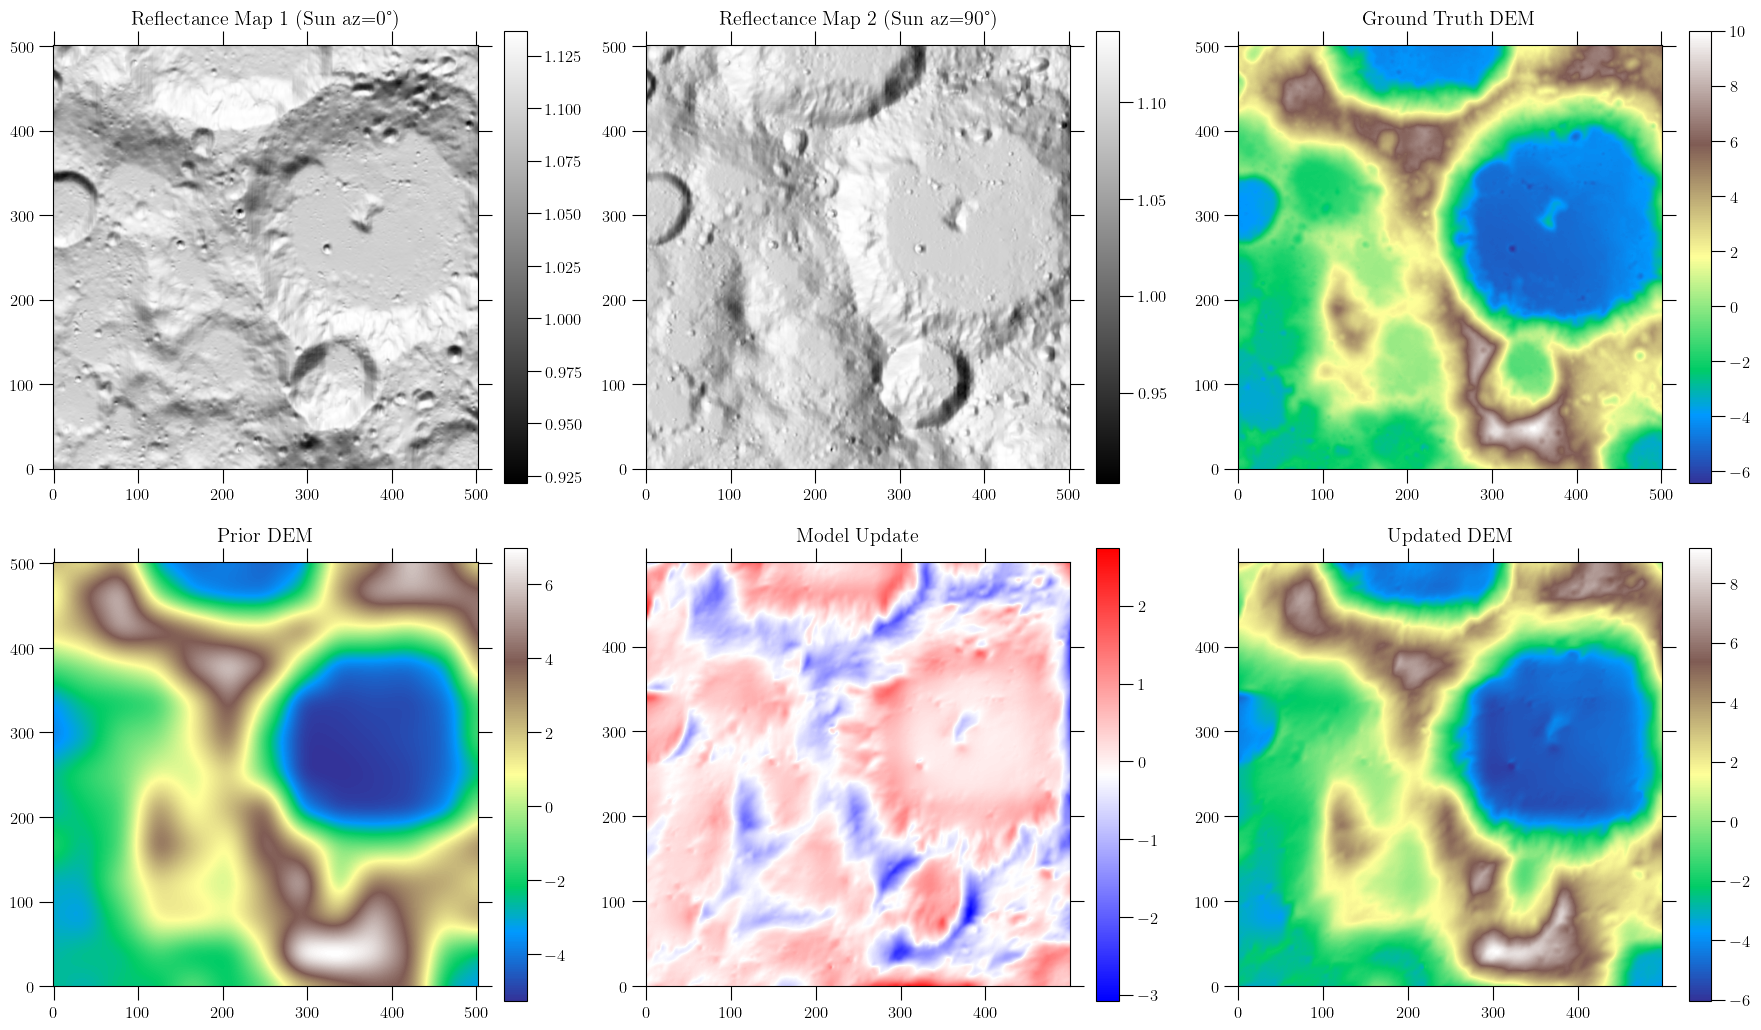

In [ ]:
M_updated = normal_solver.dem_prior[1:-1, 1:-1] - M_update

# Plot: Row 1 - reflectance maps + GT DEM, Row 2 - Prior, Update, Updated DEM
fig, axes = plt.subplots(2, 3, figsize=(3*6, 2*6))

# Get reflectance maps (need to crop them to match the processed size)
reflectance_np = reflectance_map.detach().cpu().numpy()
reflectance_np_2 = reflectance_map_2.detach().cpu().numpy()

# Crop reflectance maps to match the cropped DEM (5 pixels removed from each side)
n_crop = 5
reflectance_np_cropped = reflectance_np[n_crop:-n_crop, n_crop:-n_crop]
reflectance_np_2_cropped = reflectance_np_2[n_crop:-n_crop, n_crop:-n_crop]

shrink_factor = 0.7

# Row 1: Reflectance maps and GT DEM
ax_format(axes[0, 0])
im = axes[0, 0].imshow(reflectance_np_cropped, cmap='gray', origin='lower')
axes[0, 0].set_title(f'Reflectance Map 1 (Sun az={SUN_AZ}°)', pad=15)
fig.colorbar(im, ax=axes[0, 0], shrink=shrink_factor)

ax_format(axes[0, 1])
im = axes[0, 1].imshow(reflectance_np_2_cropped, cmap='gray', origin='lower')
axes[0, 1].set_title(f'Reflectance Map 2 (Sun az={SUN_AZ_2}°)', pad=15)
fig.colorbar(im, ax=axes[0, 1], shrink=shrink_factor)

ax_format(axes[0, 2])
im = axes[0, 2].imshow(normal_solver.gt_dem, cmap='terrain', origin='lower')
axes[0, 2].set_title('Ground Truth DEM', pad=15)
fig.colorbar(im, ax=axes[0, 2], shrink=shrink_factor)

# Row 2: Prior, Update, Updated DEM
ax_format(axes[1, 0])
im = axes[1, 0].imshow(normal_solver.dem_prior, cmap='terrain', origin='lower')
axes[1, 0].set_title('Prior DEM', pad=15)
fig.colorbar(im, ax=axes[1, 0], shrink=shrink_factor)

ax_format(axes[1, 1])
im = axes[1, 1].imshow(M_update, cmap='bwr', origin='lower')
axes[1, 1].set_title('Model Update', pad=15)
fig.colorbar(im, ax=axes[1, 1], shrink=shrink_factor)

ax_format(axes[1, 2])
im = axes[1, 2].imshow(M_updated, cmap='terrain', origin='lower')
axes[1, 2].set_title('Updated DEM', pad=15)
fig.colorbar(im, ax=axes[1, 2], shrink=shrink_factor)

plt.tight_layout()
plt.subplots_adjust(hspace=-0.2)  # Adjust vertical space between rows
plt.show()

In [ ]:
print("Stats on computed model update M:")
print("Shape:", M_update.shape)
print("Min:", M_update.min())
print("Max:", M_update.max())
print("Mean:", M_update.mean())
print("Std:", M_update.std())

print("Stats on updated DEM (prior + M):")
print("Shape:", M_updated.shape)
print("Min:", M_updated.min())
print("Max:", M_updated.max())
print("Mean:", M_updated.mean())
print("Std:", M_updated.std())

print("Stats on prior DEM (center-cropped):")
print("Shape:", normal_solver.dem_prior[1:-1, 1:-1].shape)
print("Min:", normal_solver.dem_prior[1:-1, 1:-1].min())
print("Max:", normal_solver.dem_prior[1:-1, 1:-1].max())
print("Mean:", normal_solver.dem_prior[1:-1, 1:-1].mean())
print("Std:", normal_solver.dem_prior[1:-1, 1:-1].std())

Stats on computed model update M:


NameError: name 'M_update' is not defined

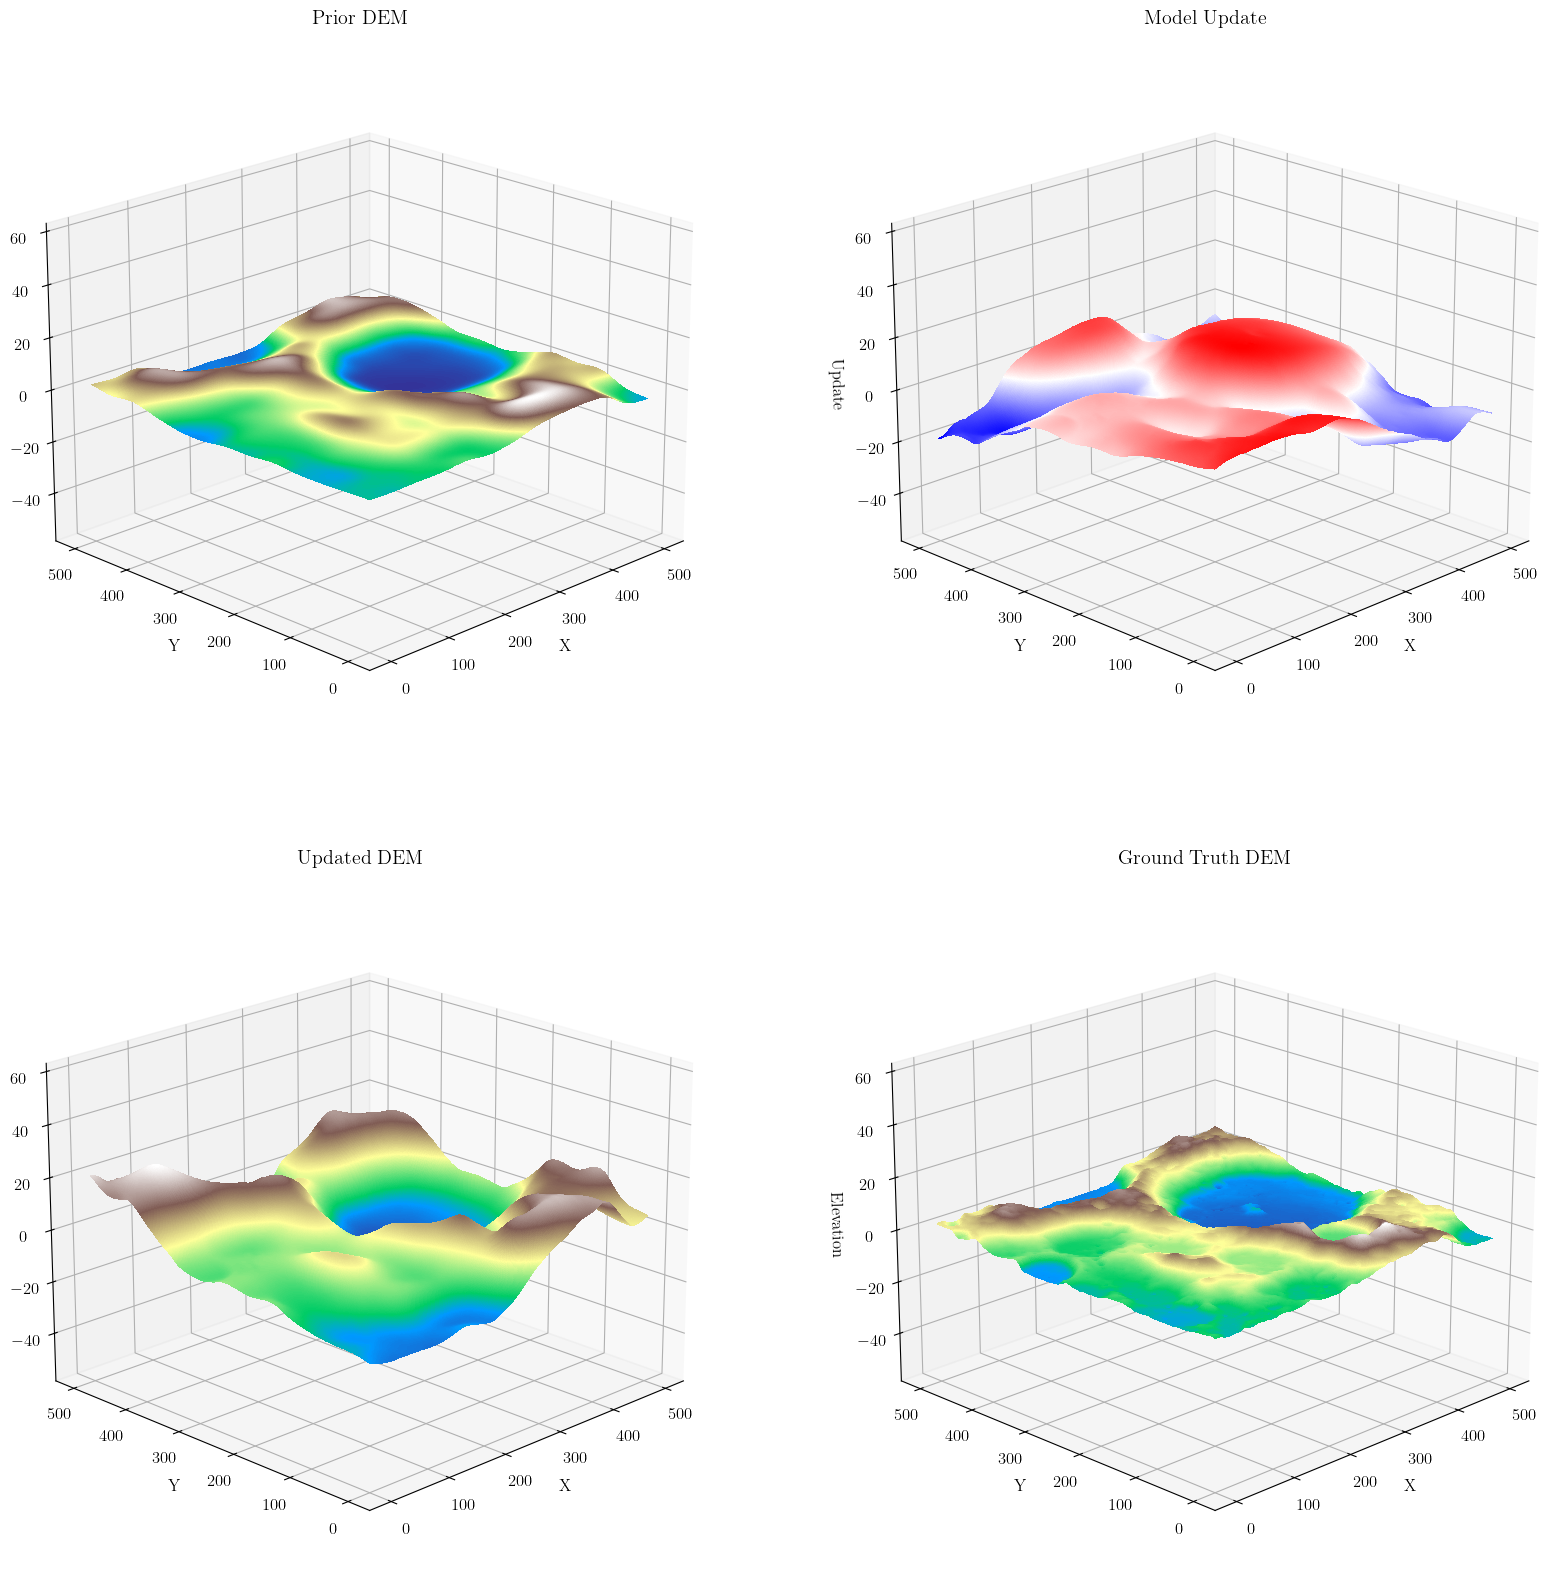

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(20, 20))
z_pad_min = 40
z_pad_max = 40
z_min = min(normal_solver.gt_dem.min(), normal_solver.dem_prior.min(), M_update.min(), M_updated.min()) - z_pad_min
z_max = max(normal_solver.gt_dem.max(), normal_solver.dem_prior.max(), M_update.max(), M_updated.max()) + z_pad_max
elevation_angle = 20
azimuth_angle = 45
alpha = 1

fig.set_dpi(100)

X = np.arange(normal_solver.gt_dem.shape[1])
Y = np.arange(normal_solver.gt_dem.shape[0])
X, Y = np.meshgrid(X, Y)

X_update = np.arange(M_update.shape[1])
Y_update = np.arange(M_update.shape[0])
X_update, Y_update = np.meshgrid(X_update, Y_update)

# Prior DEM
ax0 = fig.add_subplot(2, 2, 1, projection='3d')
ax0.plot_surface(X, Y, normal_solver.dem_prior, cmap='terrain', edgecolor='none', rstride=1, cstride=1, antialiased=False)
ax0.invert_yaxis()
ax0.invert_xaxis()
ax0.set_zlim(z_min, z_max)
ax0.view_init(elev=elevation_angle, azim=azimuth_angle)
ax0.set_title('Prior DEM', pad=15)
ax0.set_xlabel('X')
ax0.set_ylabel('Y')
ax0.set_zlabel('Elevation')

# Update (M_update)
ax1 = fig.add_subplot(2, 2, 2, projection='3d')
ax1.plot_surface(X_update, Y_update, M_update, cmap='bwr', edgecolor='none',
                 alpha=alpha, rstride=1, cstride=1, antialiased=False)
ax1.invert_yaxis()
ax1.invert_xaxis()
ax1.set_zlim(z_min, z_max)
ax1.view_init(elev=elevation_angle, azim=azimuth_angle)
ax1.set_title('Model Update', pad=15)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Update')

# Updated DEM
ax2 = fig.add_subplot(2, 2, 3, projection='3d')
ax2.plot_surface(X_update, Y_update, M_updated, cmap='terrain', edgecolor='none',
                 alpha=alpha, rstride=1, cstride=1, antialiased=False)
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.set_zlim(z_min, z_max)
ax2.view_init(elev=elevation_angle, azim=azimuth_angle)
ax2.set_title('Updated DEM', pad=15)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Elevation')

# Ground Truth DEM
ax3 = fig.add_subplot(2, 2, 4, projection='3d')
ax3.plot_surface(X, Y, normal_solver.gt_dem, cmap='terrain', edgecolor='none', rstride=1, cstride=1, antialiased=False)
ax3.invert_yaxis()
ax3.invert_xaxis()
ax3.set_zlim(z_min, z_max)
ax3.view_init(elev=elevation_angle, azim=azimuth_angle)
ax3.set_title('Ground Truth DEM', pad=15)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Elevation')

plt.show()

In [ ]:
# ====================================================================
# DEMONSTRATION: Using refactored FMSolver with debug and validation
# ====================================================================

print("=" * 70)
print("REFACTORED SOLVER DEMONSTRATION")
print("=" * 70)

# Create solver with debug mode to see all intermediate steps
demo_solver = FMSolver(
    reflectance_maps=[reflectance_map, reflectance_map_2], 
    sun_azs=[SUN_AZ, SUN_AZ_2], 
    sun_el=SUN_EL, 
    gt_dem=dem, 
    scale_down_factor=40,
    sigma_smooth=10.0, 
    max_slope_prior=50, 
    noise_fraction_brightness=0.05,
    debug=True  # Outputs detailed debug information at each step
)

# The debug output above shows:
# - Coordinate system conventions (x=East, y=North, z=Up)
# - Sun vector components and validation
# - Prior covariance settings
# - Brightness covariance computation
# - Prior DEM statistics before/after smoothing

print("\n" + "=" * 70)
print("This refactored solver provides:")
print("  ✓ Comprehensive debug output at each processing step")
print("  ✓ Coordinate system validation (azimuth→vector conversion)")
print("  ✓ Normal field validation (unit length, upward pointing)")
print("  ✓ Gradient computation with sign convention documentation")
print("  ✓ Delta_X/Delta_Y assignment verification (critical for accuracy)")
print("  ✓ Utilities extracted to solver_utils.py for reusability")
print("=" * 70)